In [1]:
import math

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import qiskit_ibm_runtime

from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

In [2]:
logical_qubits = 6
physical_qubits = logical_qubits * 9

logical_range = range(0, physical_qubits - 1, 9)

In [3]:
encoder_circuit = QuantumCircuit(9, name="shor_encode_gate")

# Encoding the logical qubit into 9 physical qubits
encoder_circuit.cx(0, 3)
encoder_circuit.cx(0, 6)

encoder_circuit.h(0)
encoder_circuit.h(3)
encoder_circuit.h(6)

encoder_circuit.cx(0, 1)
encoder_circuit.cx(3, 4)
encoder_circuit.cx(6, 7)

encoder_circuit.cx(0, 2)
encoder_circuit.cx(3, 5)
encoder_circuit.cx(6, 8)

shor_encode_gate = encoder_circuit.to_instruction()

In [4]:
decoder_circuit = QuantumCircuit(9, name="shor_decode_gate")

decoder_circuit.cx(0, 1)
decoder_circuit.cx(3, 4)
decoder_circuit.cx(6, 7)

decoder_circuit.cx(0, 2)
decoder_circuit.cx(3, 5)
decoder_circuit.cx(6, 8)

decoder_circuit.ccx(1, 2, 0)
decoder_circuit.ccx(4, 5, 3)
decoder_circuit.ccx(7, 8, 6)

decoder_circuit.h(0)
decoder_circuit.h(3)
decoder_circuit.h(6)

decoder_circuit.cx(0, 3)
decoder_circuit.cx(0, 6)
decoder_circuit.ccx(3, 6, 0)

shor_decode_gate = decoder_circuit.to_instruction()

In [5]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states
 
    Here we assume all input marked states have the same number of bits
 
    Parameters:
        marked_states (str or list): Marked states of oracle
 
    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])
 
    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bit-string to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bit-string
        zero_inds = [
            ind
            for ind in range(num_qubits)
            if rev_target.startswith("0", ind)
        ]
        # Add a multi-controlled Z-gate with pre- and post-applied X-gates (open-controls)
        # where the target bit-string has a '0' entry
        if zero_inds:
            qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)
    return qc

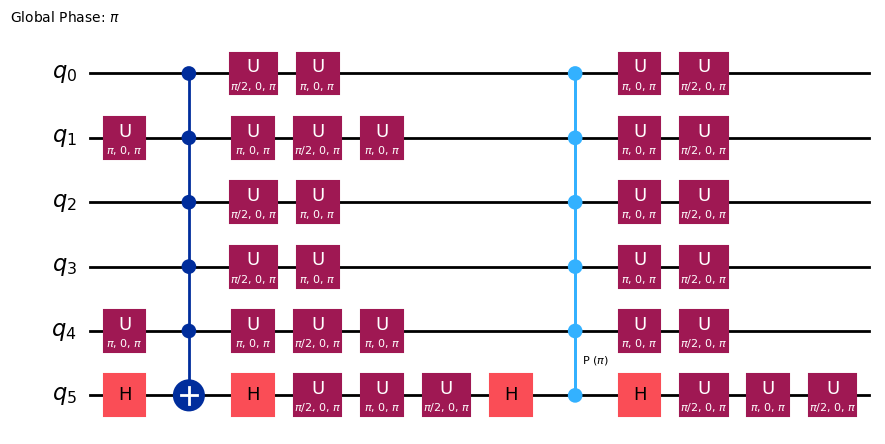

In [6]:
marked_states = ["101101"]
 
oracle = grover_oracle(marked_states)
grover_op = grover_operator(oracle)


grover_op.decompose().draw(output="mpl", style="iqp")


In [7]:
optimal_num_iterations = math.floor(
    math.pi
    / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

In [8]:
main_circuit = QuantumCircuit(physical_qubits, logical_qubits)

In [9]:
# Create even superposition of all basis states
main_circuit.h(logical_range)

In [10]:
for i in range(logical_qubits):
    main_circuit.append(shor_encode_gate, range(i*9, (i+1)*9))

In [11]:
for i in range(logical_qubits):
    main_circuit.append(shor_decode_gate, range(i*9, (i+1)*9))

In [12]:
# Apply Grover operator the optimal number of times
for _ in range(optimal_num_iterations):
    main_circuit.compose(grover_op, qubits=logical_range, inplace=True)
    
    for i in range(logical_qubits):
        main_circuit.append(shor_encode_gate, range(i*9, (i+1)*9))

    for i in range(logical_qubits):
        main_circuit.append(shor_decode_gate, range(i*9, (i+1)*9))

In [13]:
main_circuit.measure(qubit=logical_range, cbit=range(logical_qubits))

In [ ]:
main_circuit.draw()

In [15]:
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circuit_isa = pm.run(main_circuit)

In [16]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10_000
result = sampler.run([circuit_isa]).result()


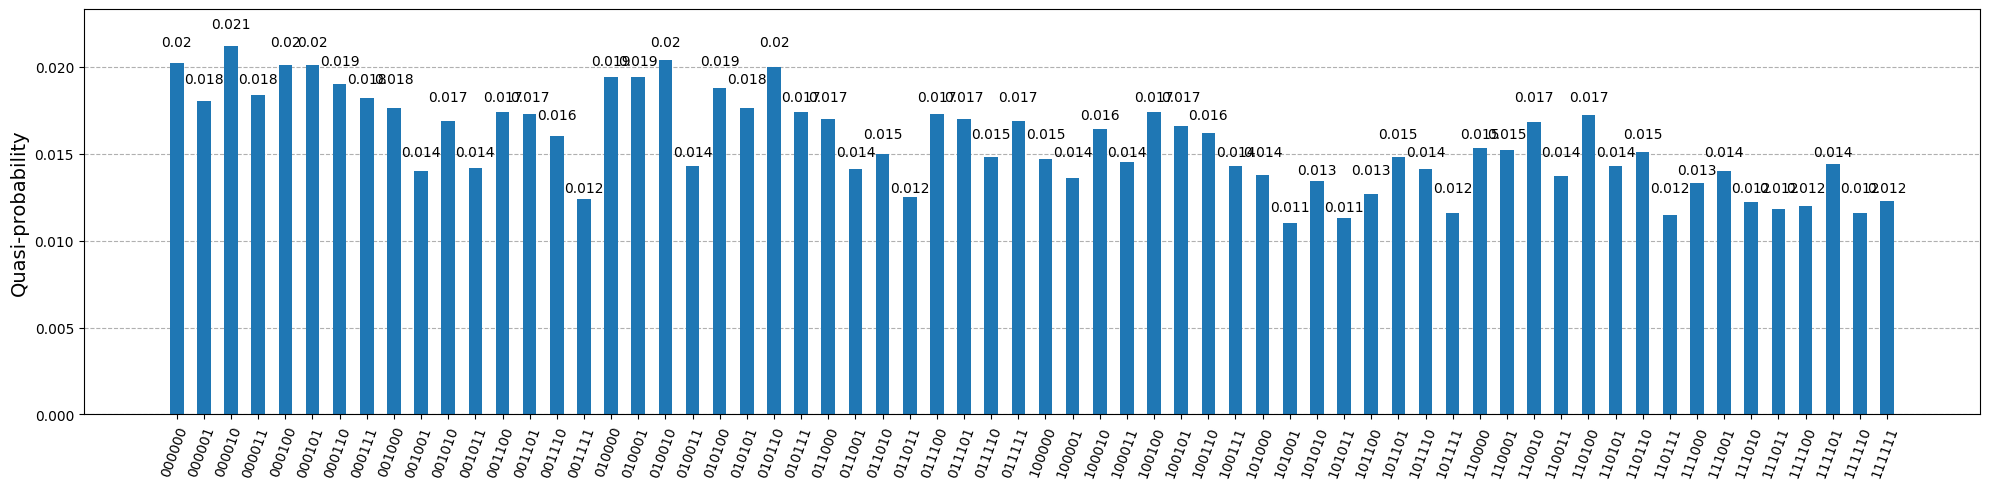

In [17]:
dist = result[0].data.c.get_counts()
plot_distribution(dist, figsize=(20, 5))

In [ ]:
# noise_model = NoiseModel.from_backend(QiskitRuntimeService().backend("ibm_fez"))

# simulator = AerSimulator(noise_model=noise_model) # noise_model=noise_model method="extended_stabilizer"

# transpiled_circuit = transpile(main_circuit, simulator)

# transpiled_circuit.draw()

In [ ]:
results = simulator.run(transpiled_circuit, shots=1024).result()

In [ ]:
counts = results.get_counts(transpiled_circuit)

plot_histogram(counts)